<a href="https://colab.research.google.com/github/najahtulakma/Finlatics/blob/main/Banking_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



Load Dataset

In [4]:
df = pd.read_csv("/banking_data.csv")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45216 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45216 non-null  int64 
 1   job             45216 non-null  object
 2   marital         45213 non-null  object
 3   marital_status  45213 non-null  object
 4   education       45213 non-null  object
 5   default         45216 non-null  object
 6   balance         45216 non-null  int64 
 7   housing         45216 non-null  object
 8   loan            45216 non-null  object
 9   contact         45216 non-null  object
 10  day             45216 non-null  int64 
 11  month           45216 non-null  object
 12  day_month       45216 non-null  object
 13  duration        45216 non-null  int64 
 14  campaign        45216 non-null  int64 
 15  pdays           45216 non-null  int64 
 16  previous        45216 non-null  int64 
 17  poutcome        45216 non-null  object
 18  y     

,age,balance,day,duration,campaign,pdays,previous
count,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000
mean,40.938186,1362.277844,15.806507,258.166202,2.763668,40.202428,0.580657
std,10.621249,3044.609674,8.322022,257.515482,3.097896,100.128248,2.303778
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.500000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Data Cleaning


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,3
marital_status,3
education,3
default,0
balance,0
housing,0
loan,0
contact,0


In [ ]:
df.head()

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no


In [ ]:
df.fillna(method = 'ffill', inplace = True)

/tmp/ipykernel_1077/3916497771.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = 'ffill', inplace = True)


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace = True)

Question 1 - Age Distribution

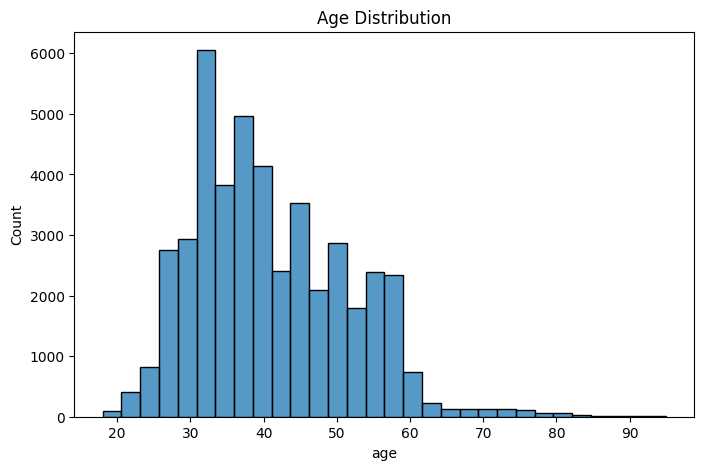

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"],bins=30)
plt.title("Age Distribution")
plt.show()

Question 2 - Job Variation

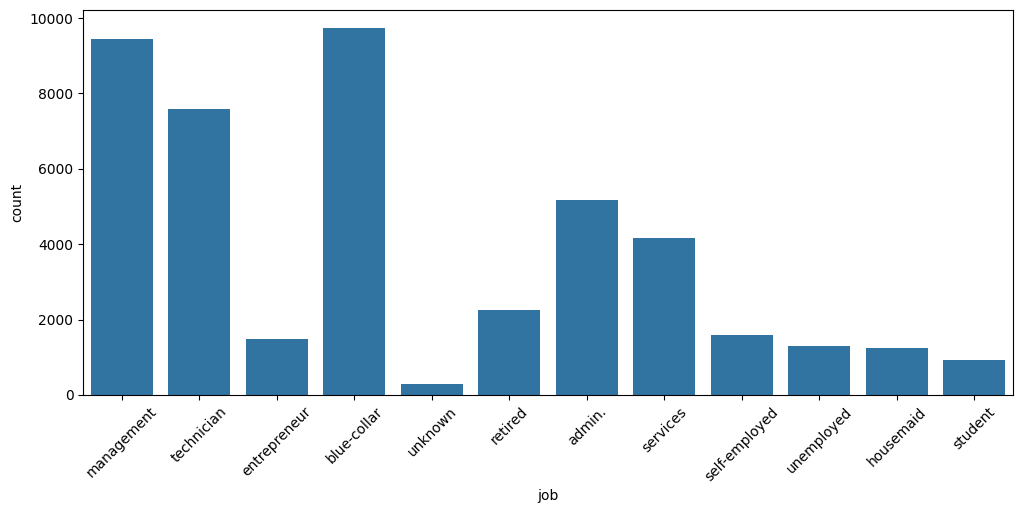

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="job")
plt.xticks(rotation=45)
plt.show()

Question 3 - Marital Status Distribution

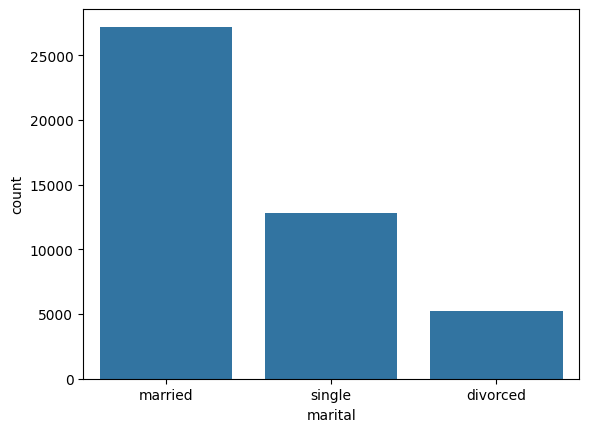

In [ ]:
sns.countplot(data=df,x="marital")
plt.show()

Question 4 - Education Level Among Client

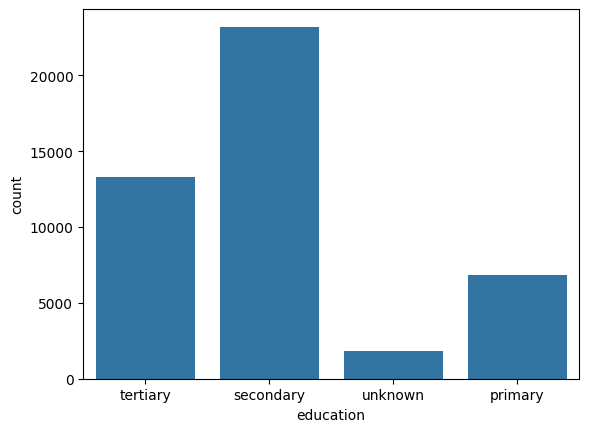

In [ ]:
sns.countplot(data=df,x="education")
plt.show()

Question 5 - Proportion of client that have credit in default

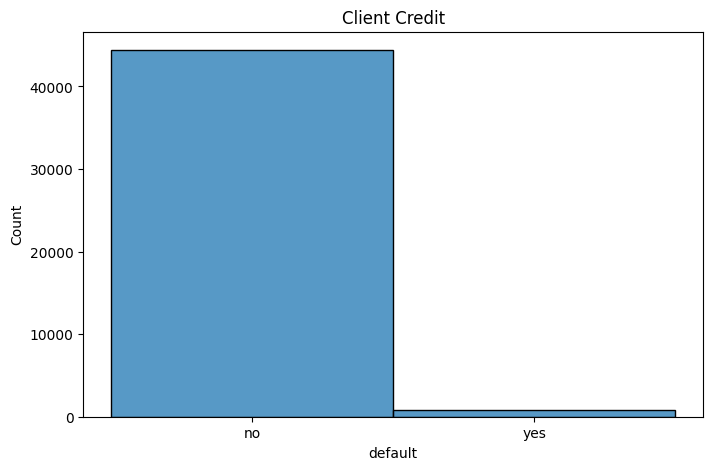

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["default"],bins=30)
plt.title("Client Credit")
plt.show()

Question 6 - Distribution of average yearly balance among client

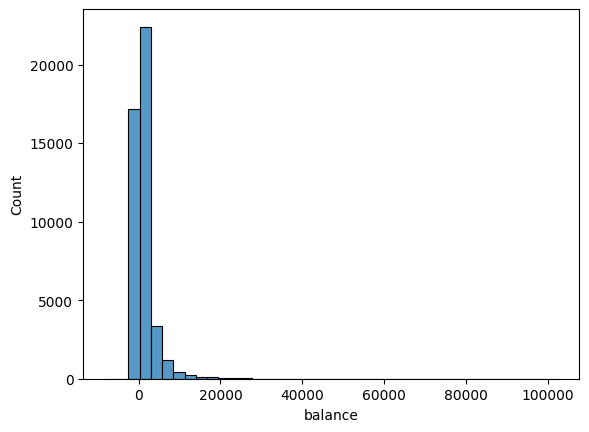

In [7]:
sns.histplot(df["balance"], bins =40)
plt.show()

Question 7 - Count Client that has housing loan

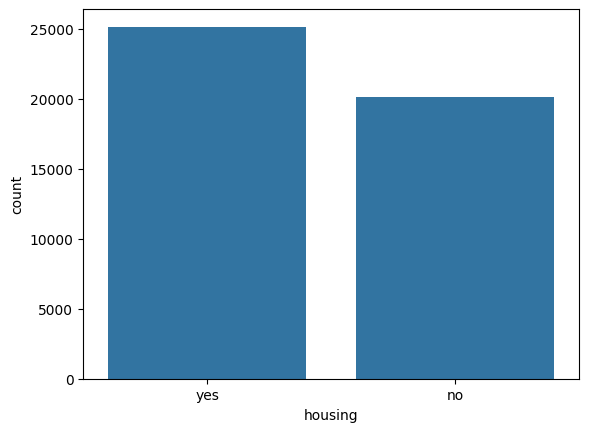

In [12]:
sns.countplot(data=df, x = "housing")
plt.show()

Question 8 - Client that has personal loan

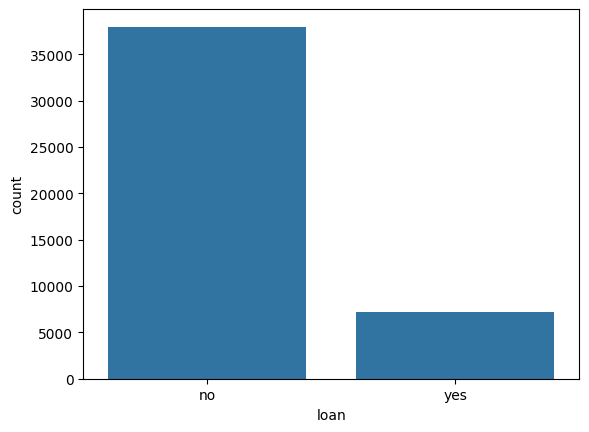

In [13]:
sns.countplot(data = df, x = "loan")
plt.show()

Question 9 - Communication Type

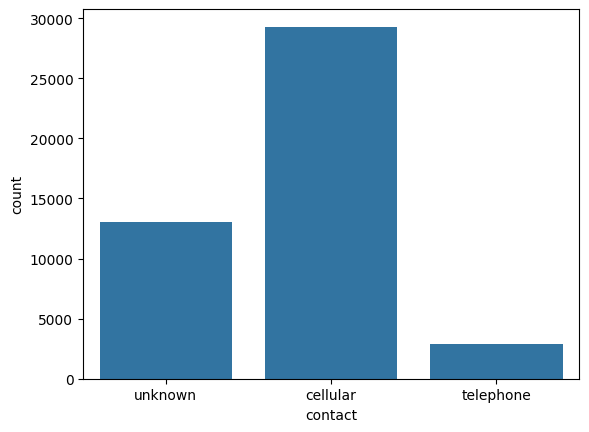

In [14]:
sns.countplot(data = df, x = "contact")
plt.show()

Question 10 - Distribution of Last Contact

day
1      322
2     1293
3     1079
4     1445
5     1910
6     1932
7     1817
8     1842
9     1561
10     524
11    1479
12    1603
13    1585
14    1848
15    1703
16    1417
17    1942
18    2308
19    1757
20    2752
21    2026
22     905
23     939
24     447
25     840
26    1035
27    1121
28    1830
29    1745
30    1566
31     643
Name: count, dtype: int64


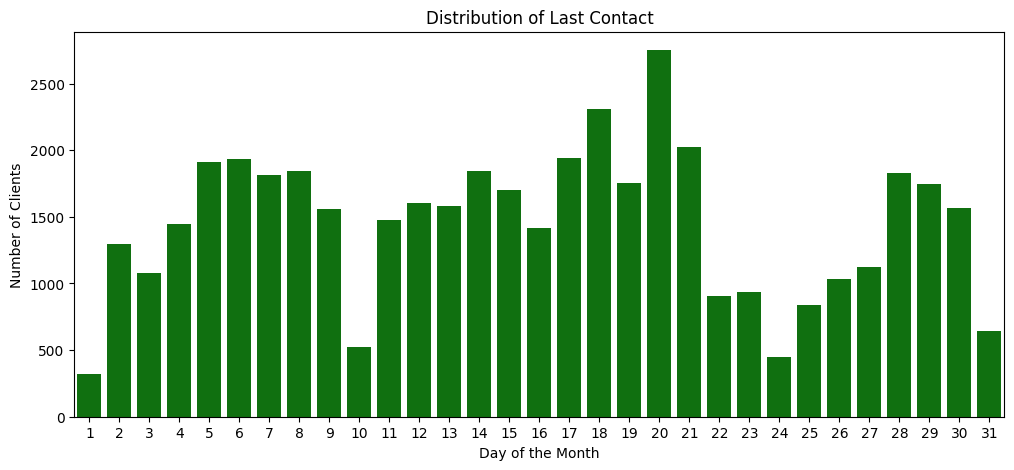

In [19]:
day_counts = df['day'].value_counts().sort_index()
print(day_counts)

plt.figure(figsize=(12,5))

sns.countplot(data = df, x ='day', color = 'green')

plt.title("Distribution of Last Contact")
plt.xlabel("Day of the Month")
plt.ylabel("Number of Clients")
plt.show()

Question 11 - How does the last contact month vary among the clients?

```
# This is formatted as code
```



month
may    13766
jul     6895
aug     6247
jun     5341
nov     3975
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
month
jan     1403
feb     2649
mar      477
apr     2932
may    13766
jun     5341
jul     6895
aug     6247
sep      579
oct      738
nov     3975
dec      214
Name: count, dtype: int64


/tmp/ipykernel_1111/4230400862.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


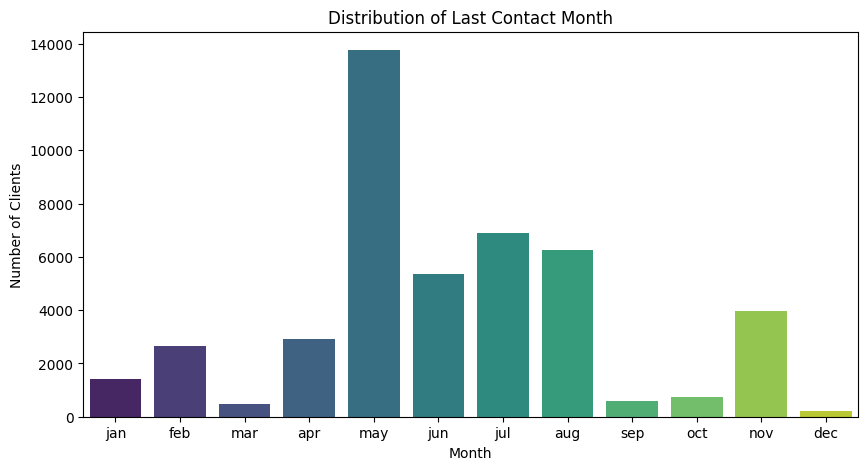

In [21]:
month_counts = df['month'].value_counts()
print(month_counts)

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_counts =df['month'].value_counts().reindex(month_order)
print(month_counts)

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='month',
    order=month_order,
    palette='viridis'
)

plt.title('Distribution of Last Contact Month')
plt.xlabel('Month')
plt.ylabel('Number of Clients')

plt.show()

Question 12 - What is the distribution of the duration of the last contact?

count    45216.000000
mean       258.166202
std        257.515482
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64


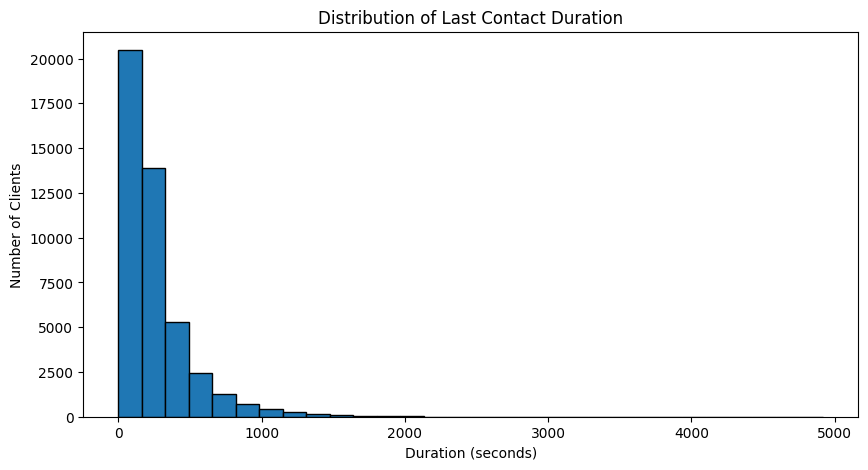

In [24]:
print(df['duration'].describe())

plt.figure(figsize = (10,5))

plt.hist(df['duration'], bins= 30,edgecolor = 'black')

plt.title('Distribution of Last Contact Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Clients')

plt.show()

Question 13 - How many contacts were performed during the campaign for each client?

In [27]:
campaign_counts = df['campaign'].value_counts().sort_index()
print(campaign_counts)



campaign
1     17548
2     12506
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
16       79
17       69
18       51
19       44
20       43
21       35
22       23
23       22
24       20
25       22
26       13
27       10
28       16
29       16
30        8
31       12
32        9
33        6
34        5
35        4
36        4
37        2
38        3
39        1
41        2
43        3
44        1
46        1
50        2
51        1
55        1
58        1
63        1
Name: count, dtype: int64


Question 14 - What is the distribution of the number of days passed since the client was last contacted
from a previous campaign?

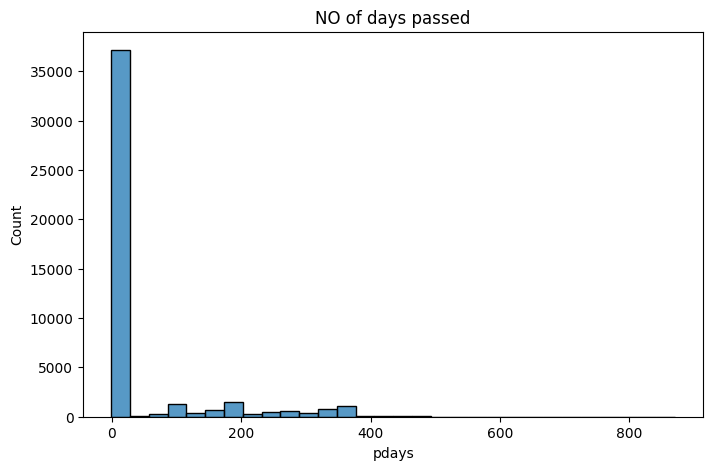

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["pdays"],bins=30)
plt.title("NO of days passed")
plt.show()

Question 15 - How many contacts were performed before the current campaign for each client?

In [29]:
campaign_counts = df['previous'].value_counts().sort_index()
print(campaign_counts)


previous
0      36956
1       2772
2       2106
3       1142
4        715
5        459
6        278
7        205
8        130
9         92
10        67
11        65
12        44
13        38
14        19
15        20
16        13
17        15
18         6
19        11
20         8
21         4
22         6
23         8
24         5
25         4
26         2
27         5
28         2
29         4
30         3
32         1
35         1
37         2
38         2
40         1
41         1
51         1
55         1
58         1
275        1
Name: count, dtype: int64


Question 16 - What were the outcomes of the previous marketing campaigns?

In [30]:
poutcome_counts = df['poutcome'].value_counts()
print(poutcome_counts)

poutcome
unknown    36961
failure     4902
other       1840
success     1513
Name: count, dtype: int64


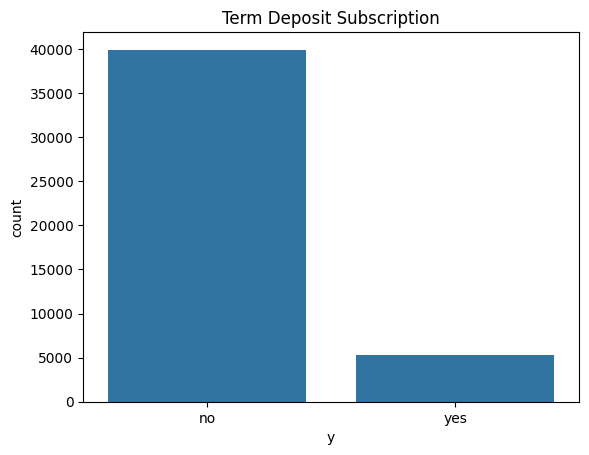

In [32]:
sns.countplot(data = df, x ="y")
plt.title("Term Deposit Subscription")
plt.show()

In [36]:
encoder = LabelEncoder()

for column in df.columns:
  if df[column].dtype =="object":
    df[column] = encoder.fit_transform(df[column])

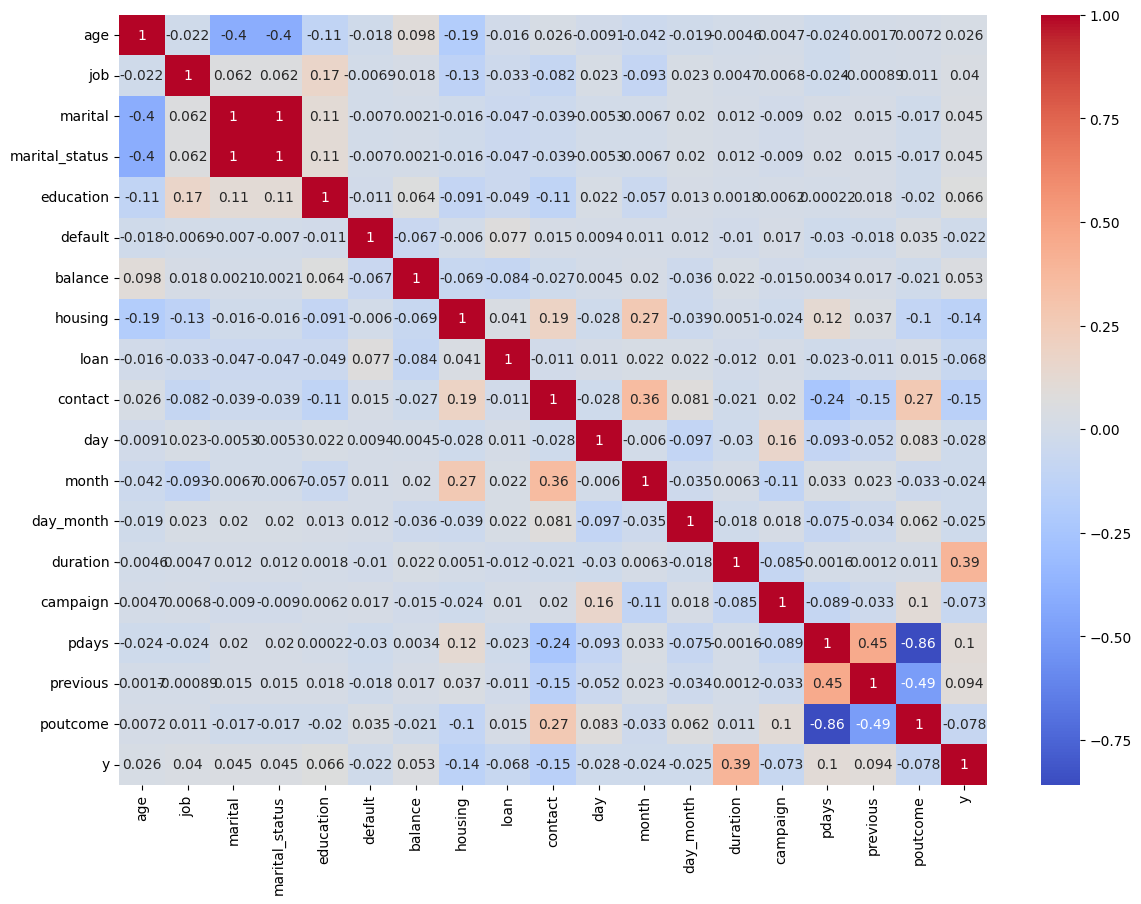

In [37]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [38]:
X = df.drop("y", axis=1)

y = df["y"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()

model1.fit(X_train, y_train)

prediction1 = model1.predict(X_test)

In [42]:
accuracy_score(y_test, prediction1)

0.8871074745687749

Model 2 - Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=42)

model2.fit(X_train, y_train)

prediction2 = model2.predict(X_test)

accuracy_score(y_test,prediction2)

0.8708536045997346

Model 3 - Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(random_state=42)

model3.fit(X_train,y_train)

prediction3 = model3.predict(X_test)

accuracy_score(y_test,prediction3)

0.9020344980097302

Model 4 - KNN

In [45]:
from sklearn.neighbors import KNeighborsClassifier

model4 = KNeighborsClassifier()

model4.fit(X_train,y_train)

prediction4 = model4.predict(X_test)

accuracy_score(y_test,prediction4)

0.8890977443609023

Model Evaluation

In [46]:
print(classification_report(y_test,prediction3))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7975
           1       0.63      0.42      0.50      1069

    accuracy                           0.90      9044
   macro avg       0.78      0.69      0.72      9044
weighted avg       0.89      0.90      0.89      9044



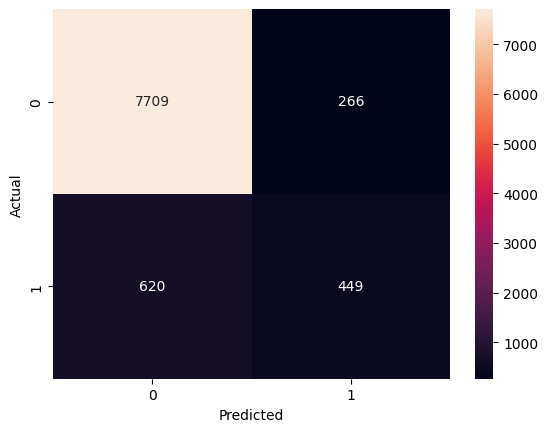

In [47]:
cm = confusion_matrix(y_test,prediction3)

sns.heatmap(cm,
            annot=True,
            fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()